In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the spatial data (Point to the .shp file!)
shapefile_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Counties\CA_Counties.shp"
gdf = gpd.read_file(shapefile_path)

# 2. Load your tabular data
df = pd.read_csv("2024_output/combined_races.csv")
selected_races = ['AD-58', 'CD-13', 'CD-21', 'CD-22', 'CD-40', 'CD-41', 'CD-45', 'CD-47', 'CD-49', 'CD-9', 'SD-19', 'SD-37', 'SD-5']
df = df[df["Race"].isin(selected_races)]
df = pd.DataFrame(df["Jurisdiction"].unique(), columns=["Jurisdiction"])

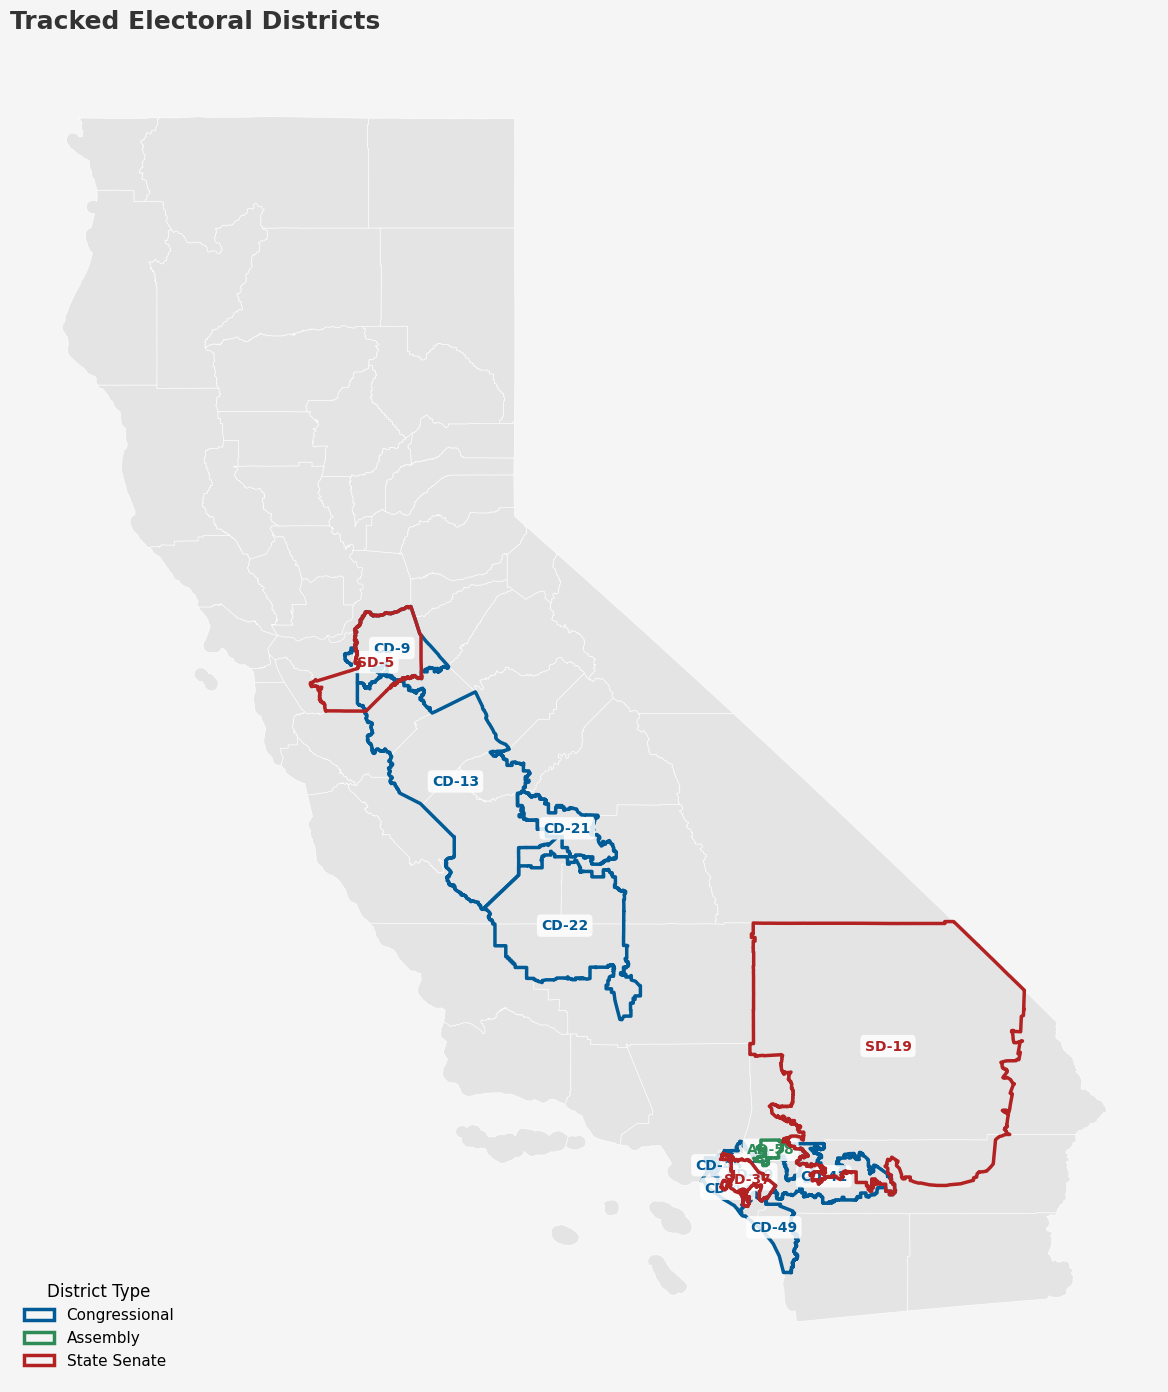

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Load the CSV data and extract the tracked district numbers
df = pd.read_csv("2024_output/combined_races.csv")
df = df[df["Race"].isin(selected_races)]

# Extract district numbers, clean them, and convert to strings
# Note: .str.lstrip('0') ensures that '05' from a shapefile matches '5' from your CSV
tracked_cds = df.loc[df['Race'].str.startswith('CD-'), 'Race'].str.replace('CD-', '').astype(str).str.lstrip('0').tolist()
tracked_ads = df.loc[df['Race'].str.startswith('AD-'), 'Race'].str.replace('AD-', '').astype(str).str.lstrip('0').tolist()
tracked_sds = df.loc[df['Race'].str.startswith('SD-'), 'Race'].str.replace('SD-', '').astype(str).str.lstrip('0').tolist()

# 2. Define file paths (using .shp)
counties_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Counties\CA_Counties.shp"
assembly_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Assembly_Districts\CA_State_Assembly_Districts_and_Membership_2024_to_2026.shp"
congress_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Congressional_Districts\Congressional_Districts.shp"
senate_path   = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Senate_Districts\CA_State_Senate_Districts_and_Membership_2025-2030.shp"

# 3. Load the Shapefiles
gdf_counties = gpd.read_file(counties_path)
gdf_assembly = gpd.read_file(assembly_path)
gdf_congress = gpd.read_file(congress_path)
gdf_senate   = gpd.read_file(senate_path)

# 4. ALIGN CRS
target_crs = gdf_counties.crs
gdf_assembly = gdf_assembly.to_crs(target_crs)
gdf_congress = gdf_congress.to_crs(target_crs)
gdf_senate   = gdf_senate.to_crs(target_crs)

# 5. Filter shapefiles using the provided column names
cd_col = 'CD119FP'
ad_col = 'DISTRICT'
sd_col = 'district'

# Clean the shapefile columns the same way (strip leading zeros to ensure a perfect match)
matched_congress = gdf_congress[gdf_congress[cd_col].astype(str).str.lstrip('0').isin(tracked_cds)]
matched_assembly = gdf_assembly[gdf_assembly[ad_col].astype(str).str.lstrip('0').isin(tracked_ads)]
matched_senate   = gdf_senate[gdf_senate[sd_col].astype(str).str.lstrip('0').isin(tracked_sds)]

# 6. Plotting
fig, ax = plt.subplots(1, 1, figsize=(12, 14), facecolor='#F5F5F5')

# Layer 1: Base Map (Counties)
gdf_counties.plot(ax=ax, color='#E0E0E0', edgecolor='#FFFFFF', linewidth=0.5, alpha=0.8)

# Layer 2: Outlines for Tracked Districts
if not matched_congress.empty:
    matched_congress.plot(ax=ax, facecolor='none', edgecolor='#005B96', linewidth=2.5, zorder=3)

if not matched_assembly.empty:
    matched_assembly.plot(ax=ax, facecolor='none', edgecolor='#2E8B57', linewidth=2.5, zorder=4)

if not matched_senate.empty:
    matched_senate.plot(ax=ax, facecolor='none', edgecolor='#B22222', linewidth=2.5, zorder=5)

# Layer 3: Labels in the middle (Centroid)
def add_labels(gdf, district_type, col_name, color):
    for idx, row in gdf.iterrows():
        centroid = row.geometry.centroid
        dist_num = str(row[col_name]).lstrip('0')
        label_text = f"{district_type}-{dist_num}"
        
        ax.annotate(text=label_text, 
                    xy=(centroid.x, centroid.y), 
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10,
                    fontweight='600',
                    fontfamily='sans-serif',
                    color=color,
                    bbox=dict(facecolor='#FFFFFF', alpha=0.85, edgecolor='none', pad=2, boxstyle='round,pad=0.3'))

add_labels(matched_congress, 'CD', cd_col, '#005B96')
add_labels(matched_assembly, 'AD', ad_col, '#2E8B57')
add_labels(matched_senate, 'SD', sd_col, '#B22222')

ax.axis('off')
plt.title('Tracked Electoral Districts', fontsize=18, fontweight='bold', pad=20, loc='left', color='#333333')

blue_patch = mpatches.Patch(edgecolor='#005B96', facecolor='none', label='Congressional', linewidth=2.5)
green_patch = mpatches.Patch(edgecolor='#2E8B57', facecolor='none', label='Assembly', linewidth=2.5)
red_patch = mpatches.Patch(edgecolor='#B22222', facecolor='none', label='State Senate', linewidth=2.5)

plt.legend(handles=[blue_patch, green_patch, red_patch], 
           loc='lower left', 
           frameon=False,
           fontsize=11,
           title='District Type',
           title_fontsize=12)

plt.tight_layout()
plt.show()

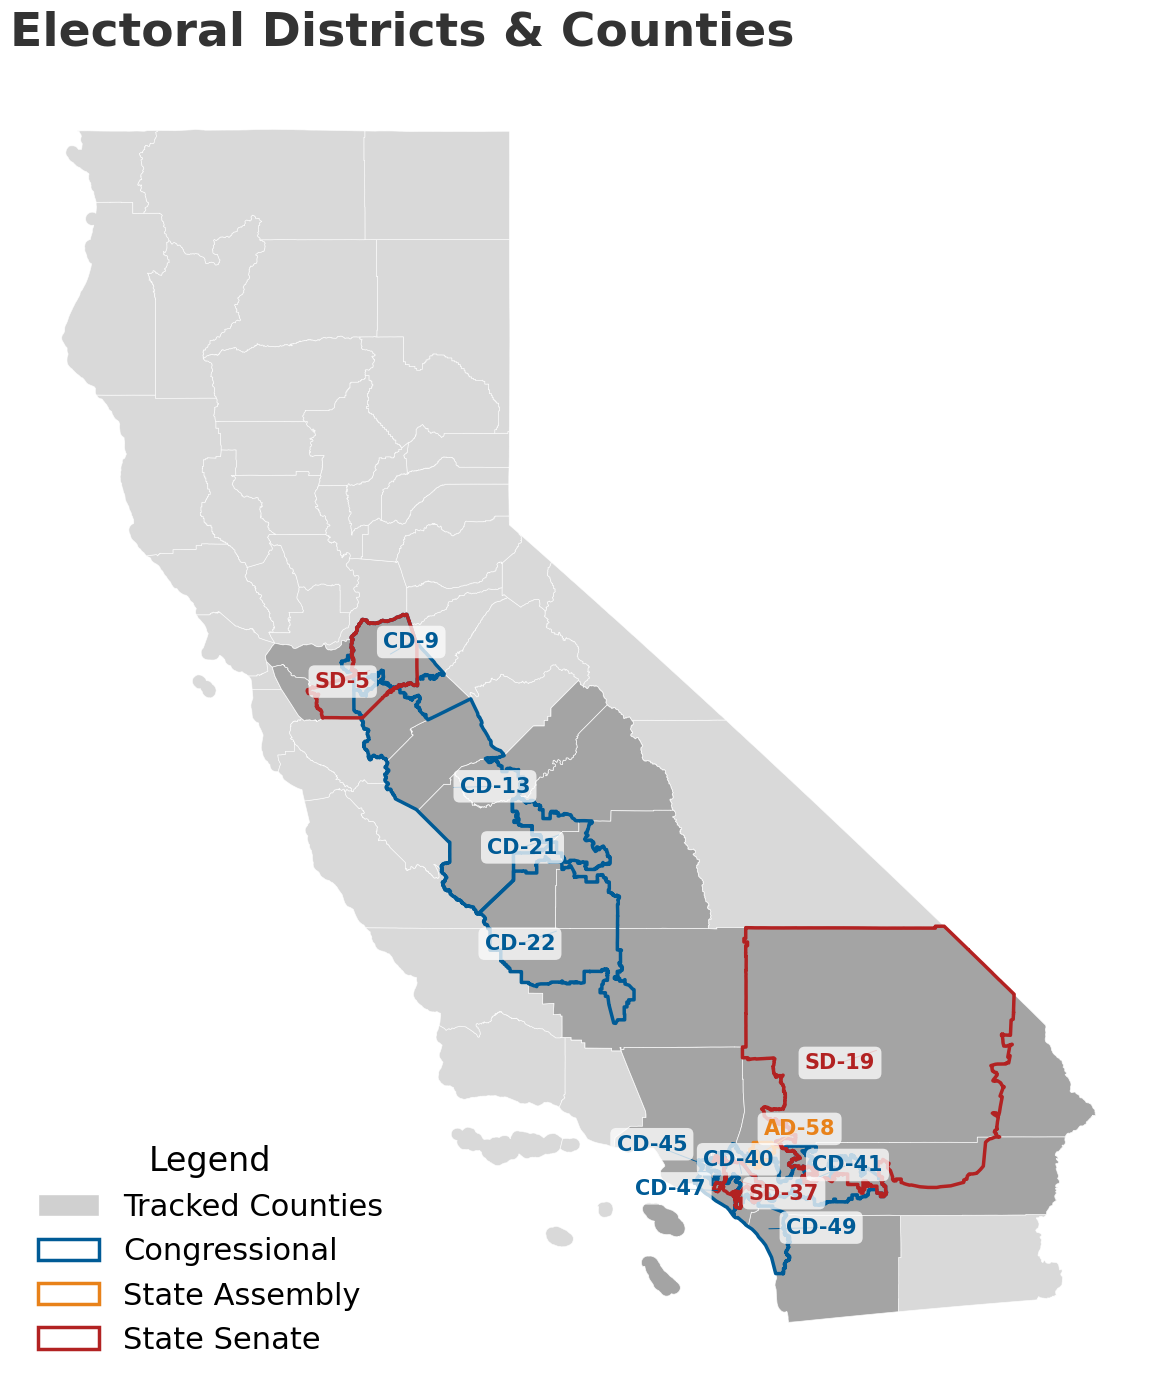

In [29]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from adjustText import adjust_text

CD_COLOR = '#005B96'
AD_COLOR = '#E8821A'   # light orange
SD_COLOR = '#B22222'

# Extract district numbers, clean them, and convert to strings
tracked_cds = df.loc[df['Race'].str.startswith('CD-'), 'Race'].str.replace('CD-', '').astype(str).str.lstrip('0').tolist()
tracked_ads = df.loc[df['Race'].str.startswith('AD-'), 'Race'].str.replace('AD-', '').astype(str).str.lstrip('0').tolist()
tracked_sds = df.loc[df['Race'].str.startswith('SD-'), 'Race'].str.replace('SD-', '').astype(str).str.lstrip('0').tolist()

tracked_counties = df['Jurisdiction'].dropna().str.strip().str.title().unique().tolist()

counties_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Counties\CA_Counties.shp"
assembly_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Assembly_Districts\CA_State_Assembly_Districts_and_Membership_2024_to_2026.shp"
congress_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Congressional_Districts\Congressional_Districts.shp"
senate_path   = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Senate_Districts\CA_State_Senate_Districts_and_Membership_2025-2030.shp"

gdf_counties = gpd.read_file(counties_path)
gdf_assembly = gpd.read_file(assembly_path)
gdf_congress = gpd.read_file(congress_path)
gdf_senate   = gpd.read_file(senate_path)

target_crs = gdf_counties.crs
gdf_assembly = gdf_assembly.to_crs(target_crs)
gdf_congress = gdf_congress.to_crs(target_crs)
gdf_senate   = gdf_senate.to_crs(target_crs)

cd_col = 'CD119FP'
ad_col = 'DISTRICT'
sd_col = 'district'
county_col = 'NAME'

matched_congress = gdf_congress[gdf_congress[cd_col].astype(str).str.lstrip('0').isin(tracked_cds)]
matched_assembly = gdf_assembly[gdf_assembly[ad_col].astype(str).str.lstrip('0').isin(tracked_ads)]
matched_senate   = gdf_senate[gdf_senate[sd_col].astype(str).str.lstrip('0').isin(tracked_sds)]

gdf_counties[county_col] = gdf_counties[county_col].str.strip().str.title()
matched_counties = gdf_counties[gdf_counties[county_col].isin(tracked_counties)]

fig, ax = plt.subplots(1, 1, figsize=(12, 14))
fig.patch.set_alpha(0)   # transparent figure background
ax.patch.set_alpha(0)    # transparent axes background

gdf_counties.plot(ax=ax, color='#D0D0D0', edgecolor='#FFFFFF', linewidth=0.5, alpha=0.8)
if not matched_counties.empty:
    matched_counties.plot(ax=ax, color='#A0A0A0', edgecolor='#FFFFFF', linewidth=0.5, alpha=0.9, zorder=2)

if not matched_congress.empty:
    matched_congress.plot(ax=ax, facecolor='none', edgecolor=CD_COLOR, linewidth=2.5, zorder=3)
if not matched_assembly.empty:
    matched_assembly.plot(ax=ax, facecolor='none', edgecolor=AD_COLOR, linewidth=2.5, zorder=4)
if not matched_senate.empty:
    matched_senate.plot(ax=ax, facecolor='none', edgecolor=SD_COLOR, linewidth=2.5, zorder=5)

# Collect all labels at their centroid positions
texts = []
points_x = []
points_y = []
text_colors = []

def collect_labels(gdf, district_type, col_name, color):
    for _, row in gdf.iterrows():
        centroid = row.geometry.centroid
        dist_num = str(row[col_name]).lstrip('0')
        t = ax.text(
            centroid.x, centroid.y,
            f"{district_type}-{dist_num}",
            ha='center', va='center',
            fontsize=15, fontweight='600',
            fontfamily='sans-serif',
            color=color,
            bbox=dict(facecolor='#FFFFFF', alpha=0.75, edgecolor='none', pad=2, boxstyle='round,pad=0.3'),
            zorder=10,
        )
        texts.append(t)
        points_x.append(centroid.x)
        points_y.append(centroid.y)
        text_colors.append(color)

collect_labels(matched_congress, 'CD', cd_col, CD_COLOR)
collect_labels(matched_assembly, 'AD', ad_col, AD_COLOR)
collect_labels(matched_senate,   'SD', sd_col, SD_COLOR)

# Nudge only labels that are genuinely touching (tight expand, no arrows yet)
adjust_text(texts, x=points_x, y=points_y, ax=ax, expand=(1.02, 1.02))

# Draw a leader line in the district's own color, but only for labels that actually moved
xmin, xmax = ax.get_xlim()
move_threshold = (xmax - xmin) * 0.001

for t, ox, oy, color in zip(texts, points_x, points_y, text_colors):
    nx, ny = t.get_position()
    if abs(nx - ox) > move_threshold or abs(ny - oy) > move_threshold:
        ax.annotate(
            '', xy=(ox, oy), xytext=(nx, ny),
            arrowprops=dict(arrowstyle='-', color=color, lw=0.7),
            zorder=9,
        )

ax.axis('off')
plt.title('Electoral Districts & Counties', fontsize=34, fontweight='bold', pad=0, loc='left', color='#333333')

county_patch = mpatches.Patch(facecolor='#D0D0D0', edgecolor='#FFFFFF', label='Tracked Counties')
blue_patch   = mpatches.Patch(edgecolor=CD_COLOR, facecolor='none', label='Congressional', linewidth=2.5)
orange_patch = mpatches.Patch(edgecolor=AD_COLOR, facecolor='none', label='State Assembly', linewidth=2.5)
red_patch    = mpatches.Patch(edgecolor=SD_COLOR, facecolor='none', label='State Senate', linewidth=2.5)

plt.legend(handles=[county_patch, blue_patch, orange_patch, red_patch],
           loc='lower left', frameon=False, fontsize=22,
           title='Legend', title_fontsize=24)

plt.tight_layout()
plt.show()


In [4]:
import requests
import pandas as pd

CENSUS_API_KEY = "248d098d23301209b7787752b284f976075eef4b"

# --- Fetch the actual data ---
url = "https://api.census.gov/data/2020/dec/dhc"
params = {
    "get": "group(P10)",
    "ucgid": "pseudo(0400000US06$1400000)",
    "key": CENSUS_API_KEY,
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()
df_census = pd.DataFrame(data[1:], columns=data[0])

df_census = df_census[["GEO_ID", "NAME", "P10_001N"]].rename(columns={
    "P10_001N": "total_vap"
})

df_census["total_vap"] = pd.to_numeric(df_census["total_vap"], errors="coerce")
df_census.head()


,GEO_ID,NAME,total_vap
0,1400000US06001400100,Census Tract 4001; Alameda County; California,2633
1,1400000US06001400200,Census Tract 4002; Alameda County; California,1652
2,1400000US06001400300,Census Tract 4003; Alameda County; California,4654
3,1400000US06001400400,Census Tract 4004; Alameda County; California,3421
4,1400000US06001400500,Census Tract 4005; Alameda County; California,3087


In [28]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

MIN_OVERLAP = 0.10          # exclude tracts where <10% of area falls within the county/district
MIN_COUNTY_DISTRICT = 0.01  # exclude counties where <1% of area intersects a tracked district

# --- Load tract geometries ---
tract_path = r"CCTP_data/Census_Tracts/tl_2020_06_tract.shp"
gdf_tracts = gpd.read_file(tract_path).to_crs(target_crs)
gdf_tracts["GEO_ID"] = "1400000US" + gdf_tracts["GEOID"]
gdf_tracts = gdf_tracts.merge(df_census[["GEO_ID", "total_vap"]], on="GEO_ID", how="left")
gdf_tracts["tract_area"] = gdf_tracts.geometry.area

# County total VAP — COUNTYFP from TIGER is authoritative
county_vap = gdf_tracts.groupby("COUNTYFP")["total_vap"].sum().rename("county_total_vap")

def district_county_pct(gdf_tracts, gdf_district, district_col, min_overlap=MIN_OVERLAP):
    tracts_sub = gdf_tracts[["GEO_ID", "COUNTYFP", "total_vap", "tract_area", "geometry"]].copy()

    overlay = gpd.overlay(
        tracts_sub,
        gdf_district[[district_col, "geometry"]],
        how="intersection",
        keep_geom_type=False,
    )
    overlay["overlap_frac"] = overlay.geometry.area / overlay["tract_area"]
    overlay = overlay[overlay["overlap_frac"] >= min_overlap]

    agg = (
        overlay.groupby([district_col, "COUNTYFP"])["total_vap"]
        .sum()
        .reset_index()
        .merge(county_vap, on="COUNTYFP")
    )
    agg["pct_of_county"] = agg["total_vap"] / agg["county_total_vap"]
    return agg

pct_congress = district_county_pct(gdf_tracts, gdf_congress, cd_col)
pct_assembly = district_county_pct(gdf_tracts, gdf_assembly, ad_col)
pct_senate   = district_county_pct(gdf_tracts, gdf_senate,   sd_col)

pct_congress.head()


,CD119FP,COUNTYFP,total_vap,county_total_vap,pct_of_county
0,01,007,168339,168339,1.0
1,01,011,15733,15733,1.0
2,01,021,21464,21464,1.0
3,01,035,27226,27226,1.0
4,01,049,6905,6905,1.0


In [ ]:
# Build COUNTYFP → county name from Census GEO_ID / NAME columns
# GEO_ID format: "1400000US06{COUNTYFP}{TRACTCE}", county FIPS is chars 11-14
county_name_map = (
    df_census
    .assign(
        COUNTYFP=df_census["GEO_ID"].str[11:14],
        county_name=(
            df_census["NAME"]
            .str.split(";").str[1]
            .str.strip()
            .str.replace(" County", "", regex=False)
        )
    )
    [["COUNTYFP", "county_name"]]
    .drop_duplicates()
)

def make_readable(df, district_col, prefix):
    return (
        df
        .merge(county_name_map, on="COUNTYFP", how="left")
        .assign(district=prefix + df[district_col].astype(str).str.lstrip("0"))
        .rename(columns={"county_name": "county", "total_vap": "district_vap"})
        [["district", "county", "district_vap", "county_total_vap", "pct_of_county"]]
        .sort_values(["district", "county"])
        .reset_index(drop=True)
    )

pct_congress_clean = make_readable(pct_congress, cd_col, "CD-")
pct_assembly_clean = make_readable(pct_assembly, ad_col, "AD-")
pct_senate_clean   = make_readable(pct_senate,   sd_col, "SD-")

pct_race_county = (
    pd.concat([pct_congress_clean, pct_assembly_clean, pct_senate_clean], ignore_index=True)
    .sort_values(["district", "county"])
    .reset_index(drop=True)
)

pct_race_county


,district,county,district_vap,county_total_vap,pct_of_county
0,AD-1,Alpine,1009,1009,1.000000
1,AD-1,Amador,34042,34042,1.000000
2,AD-1,El Dorado,49597,152083,0.326118
3,AD-1,Lassen,27226,27226,1.000000
4,AD-1,Modoc,6905,6905,1.000000
...,...,...,...,...,...
385,SD-7,Alameda,563675,1338388,0.421160
386,SD-7,Contra Costa,210429,902672,0.233118
387,SD-8,Sacramento,734398,1217309,0.603296
388,SD-9,Alameda,190037,1338388,0.141989


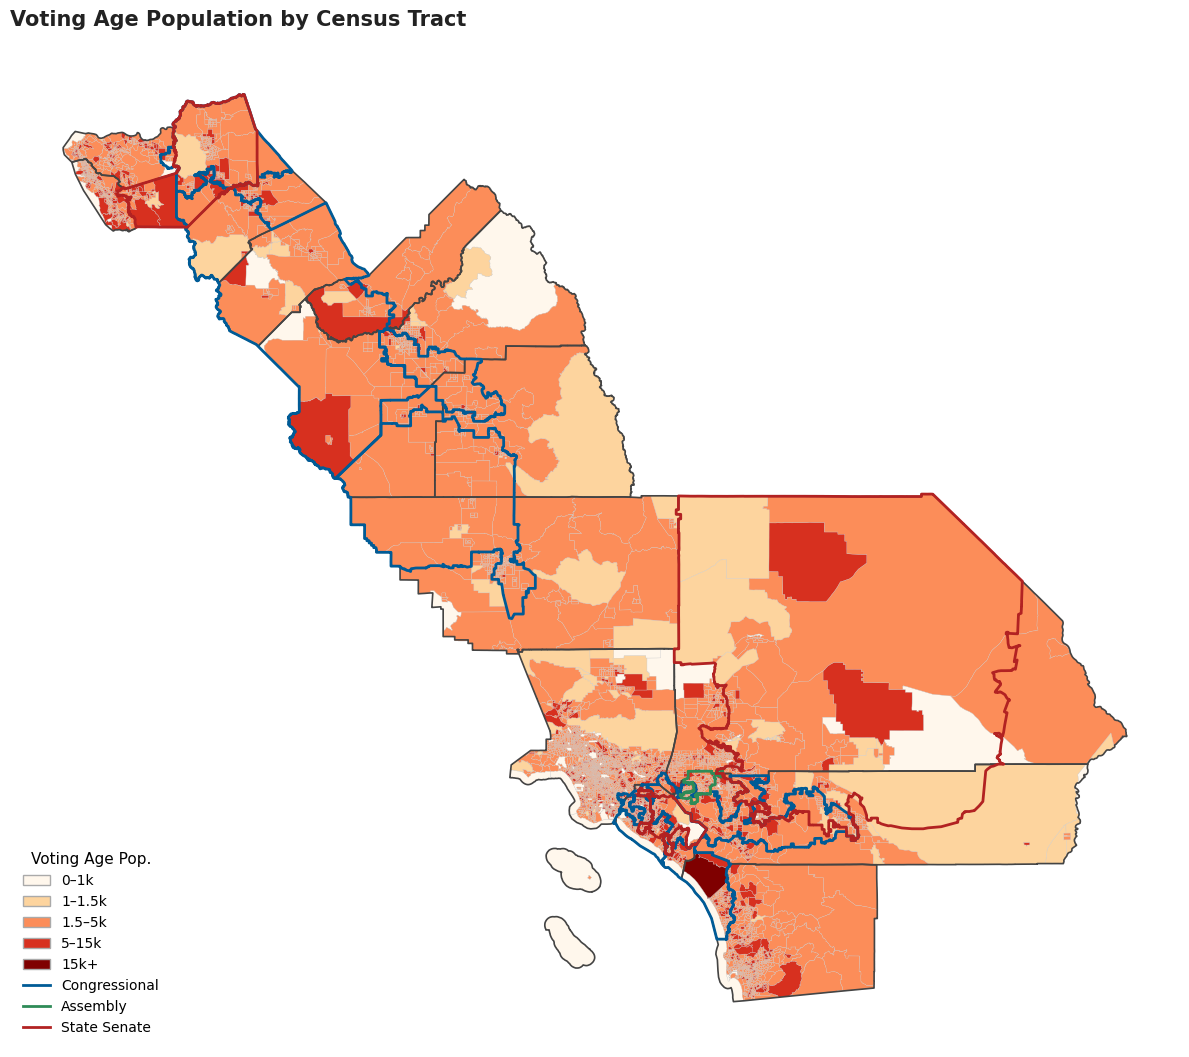

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from shapely.ops import unary_union

county_union = unary_union(matched_counties.geometry)

# Filter tracts: drop those with <10% area inside tracked counties
tracts_in_area = gpd.sjoin(
    gdf_tracts,
    matched_counties[["geometry"]],
    how="inner",
    predicate="intersects"
).drop(columns="index_right").drop_duplicates(subset="GEOID").copy()

tracts_in_area["overlap_frac"] = (
    tracts_in_area.geometry.intersection(county_union).area / tracts_in_area["tract_area"]
)
tracts_in_area = tracts_in_area[tracts_in_area["overlap_frac"] >= MIN_OVERLAP]

# Discrete VAP bins
bins   = [0, 1_000, 1_500, 5_000, 15_000, float("inf")]
labels = ["0–1k", "1–1.5k", "1.5–5k", "5–15k", "15k+"]
colors = ["#FFF7EC", "#FDD49E", "#FC8D59", "#D7301F", "#7F0000"]

tracts_in_area["vap_bin"] = pd.cut(
    tracts_in_area["total_vap"], bins=bins, labels=labels, right=False
)

# Relevant counties: tracked + those where ≥1% of county area overlaps a tracked district
all_districts_union = unary_union(pd.concat([
    matched_congress.geometry,
    matched_assembly.geometry,
    matched_senate.geometry,
]))
county_area = gdf_counties.geometry.area
district_overlap_frac = gdf_counties.geometry.intersection(all_districts_union).area / county_area
counties_with_districts = gdf_counties[district_overlap_frac >= MIN_COUNTY_DISTRICT]
relevant_counties = pd.concat([matched_counties, counties_with_districts]).drop_duplicates(subset="NAME")

# Plot
fig, ax = plt.subplots(figsize=(12, 14), facecolor="white")

matched_counties.plot(ax=ax, color="#F0F0F0", edgecolor="none")

for label, color in zip(labels, colors):
    subset = tracts_in_area[tracts_in_area["vap_bin"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="#CCCCCC", linewidth=0.2, zorder=2)

relevant_counties.plot(ax=ax, facecolor="none", edgecolor="#444444", linewidth=1.2, zorder=3)
matched_congress.boundary.plot(ax=ax, edgecolor="#005B96", linewidth=2.0, zorder=4)
matched_assembly.boundary.plot(ax=ax, edgecolor="#2E8B57", linewidth=2.0, zorder=5)
matched_senate.boundary.plot(  ax=ax, edgecolor="#B22222", linewidth=2.0, zorder=6)

ax.axis("off")
ax.set_title("Voting Age Population by Census Tract",
             fontsize=15, fontweight="bold", loc="left", color="#222222")

vap_patches = [mpatches.Patch(facecolor=c, edgecolor="#AAAAAA", label=l)
               for l, c in zip(labels, colors)]
cd_line = mlines.Line2D([], [], color="#005B96", linewidth=2, label="Congressional")
ad_line = mlines.Line2D([], [], color="#2E8B57", linewidth=2, label="Assembly")
sd_line = mlines.Line2D([], [], color="#B22222", linewidth=2, label="State Senate")

ax.legend(handles=vap_patches + [cd_line, ad_line, sd_line],
          loc="lower left", frameon=False, fontsize=10,
          title="Voting Age Pop.", title_fontsize=11)

plt.tight_layout()
plt.show()


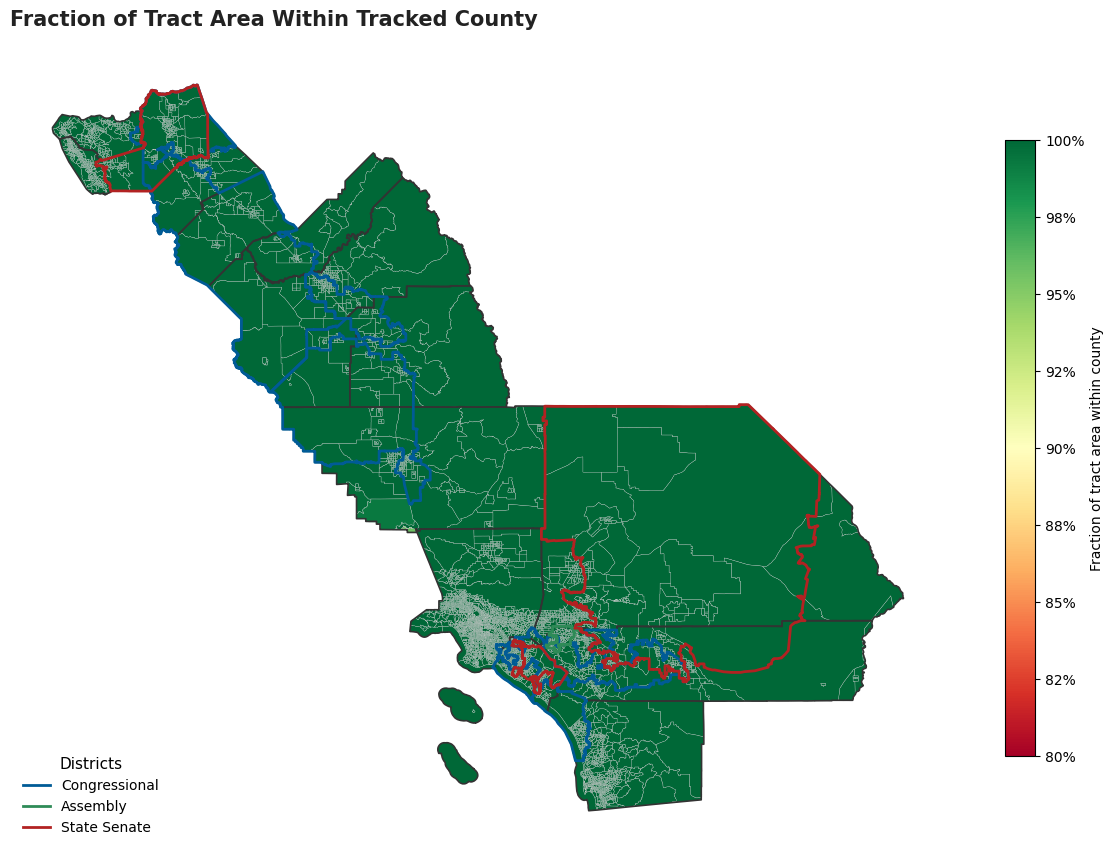

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from shapely.ops import unary_union

county_union = unary_union(matched_counties.geometry)

# Filter tracts: drop those with <10% area inside tracked counties
tracts_in_area = gpd.sjoin(
    gdf_tracts,
    matched_counties[["geometry"]],
    how="inner",
    predicate="intersects"
).drop(columns="index_right").drop_duplicates(subset="GEOID").copy()

tracts_in_area["pct_in_county"] = (
    tracts_in_area.geometry.intersection(county_union).area / tracts_in_area["tract_area"]
)
tracts_in_area = tracts_in_area[tracts_in_area["pct_in_county"] >= MIN_OVERLAP]

# Relevant counties: tracked + those where ≥1% of county area overlaps a tracked district
all_districts_union = unary_union(pd.concat([
    matched_congress.geometry,
    matched_assembly.geometry,
    matched_senate.geometry,
]))
county_area = gdf_counties.geometry.area
district_overlap_frac = gdf_counties.geometry.intersection(all_districts_union).area / county_area
counties_with_districts = gdf_counties[district_overlap_frac >= MIN_COUNTY_DISTRICT]
relevant_counties = pd.concat([matched_counties, counties_with_districts]).drop_duplicates(subset="NAME")

# Plot
fig, ax = plt.subplots(figsize=(12, 14), facecolor="white")

matched_counties.plot(ax=ax, color="#F0F0F0", edgecolor="none")

tracts_in_area.plot(
    ax=ax,
    column="pct_in_county",
    cmap="RdYlGn",
    vmin=0.8, vmax=1,
    edgecolor="#CCCCCC",
    linewidth=0.2,
    zorder=2,
    legend=True,
    legend_kwds={
        "label": "Fraction of tract area within county",
        "orientation": "vertical",
        "shrink": 0.45,
        "format": "{x:.0%}",
    },
)

relevant_counties.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.2, zorder=3)
matched_congress.boundary.plot(ax=ax, edgecolor="#005B96", linewidth=2.0, zorder=4)
matched_assembly.boundary.plot(ax=ax, edgecolor="#2E8B57", linewidth=2.0, zorder=5)
matched_senate.boundary.plot(  ax=ax, edgecolor="#B22222", linewidth=2.0, zorder=6)

ax.axis("off")
ax.set_title("Fraction of Tract Area Within Tracked County",
             fontsize=15, fontweight="bold", loc="left", color="#222222")

cd_line = mlines.Line2D([], [], color="#005B96", linewidth=2, label="Congressional")
ad_line = mlines.Line2D([], [], color="#2E8B57", linewidth=2, label="Assembly")
sd_line = mlines.Line2D([], [], color="#B22222", linewidth=2, label="State Senate")
ax.legend(handles=[cd_line, ad_line, sd_line],
          loc="lower left", frameon=False, fontsize=10,
          title="Districts", title_fontsize=11)

plt.tight_layout()
plt.show()


In [ ]:
pct_congress_clean

,district,county,district_vap,county_total_vap,pct_of_county
0,CD-1,Butte,168339,168339,1.000000
1,CD-1,Colusa,15733,15733,1.000000
2,CD-1,Glenn,21464,21464,1.000000
3,CD-1,Lassen,27226,27226,1.000000
4,CD-1,Modoc,6905,6905,1.000000
...,...,...,...,...,...
123,CD-8,Contra Costa,363900,902672,0.403136
124,CD-8,Solano,263449,354770,0.742591
125,CD-9,Contra Costa,23333,902672,0.025849
126,CD-9,San Joaquin,560432,573400,0.977384
